In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [33]:
cols = [
    "Date",
    "Time",
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

data_path = Path("household_power_consumption.txt")

df = pd.read_csv(
    data_path,
    sep=";",
    na_values="?",
    usecols=cols
)

In [34]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [35]:
df_work = df.copy()

df_work["datetime"] = pd.to_datetime(
    df_work["Date"] + " " + df_work["Time"],
    dayfirst=True
)

df_work = df_work.set_index("datetime").sort_index()

In [36]:
power_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity"
]

sub_cols = [
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

hourly_power = df_work[power_cols].resample("h").mean()
hourly_sub = df_work[sub_cols].resample("h").sum()

hourly_all = pd.concat([hourly_power, hourly_sub], axis=1)
hourly_all = hourly_all.dropna()

In [37]:
# correlation analysis

corr = hourly_all.corr()
corr

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.312322,-0.379450,0.999423,0.496310,0.440128,0.695310
Global_reactive_power,0.312322,1.000000,-0.147388,0.328446,0.328377,0.256645,0.103270
Voltage,-0.379450,-0.147388,1.000000,-0.392769,-0.207637,-0.162882,-0.277149
Global_intensity,0.999423,0.328446,-0.392769,1.000000,0.504713,0.447413,0.685515
Sub_metering_1,0.496310,0.328377,-0.207637,0.504713,1.000000,0.115583,0.195307
Sub_metering_2,0.440128,0.256645,-0.162882,0.447413,0.115583,1.000000,0.124420
Sub_metering_3,0.695310,0.103270,-0.277149,0.685515,0.195307,0.124420,1.000000


In [38]:
corr["Global_active_power"].sort_values(ascending=False)

Global_active_power      1.000000
Global_intensity         0.999423
Sub_metering_3           0.695310
Sub_metering_1           0.496310
Sub_metering_2           0.440128
Global_reactive_power    0.312322
Voltage                 -0.379450
Name: Global_active_power, dtype: float64

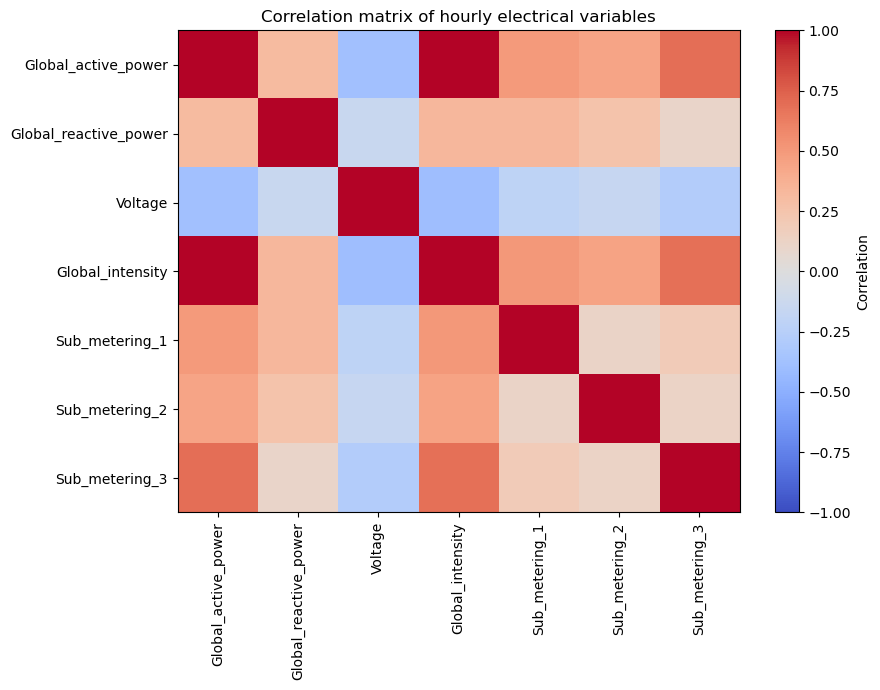

In [54]:
from pathlib import Path

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True, parents=True)

plt.figure(figsize=(9, 7))

plt.imshow(corr, 
           aspect="auto",
           cmap="coolwarm",
           vmin=-1, 
           vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation matrix of hourly electrical variables")
plt.tight_layout()

plt.savefig(figures_dir / "further_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

-1  → strong negative correlation, blue

0  → no correlation, neutral/white-ish


+1  → strong positive correlation, red

In [40]:
split_idx = int(len(hourly_all) * 0.8)

train_all = hourly_all.iloc[:split_idx]
test_all = hourly_all.iloc[split_idx:]

In [41]:
print("Train period:", train_all.index.min(), "to", train_all.index.max())
print("Test period:", test_all.index.min(), "to", test_all.index.max())

print("Train shape:", train_all.shape)
print("Test shape:", test_all.shape)

Train period: 2006-12-16 17:00:00 to 2010-02-05 04:00:00
Test period: 2010-02-05 05:00:00 to 2010-11-26 21:00:00
Train shape: (27334, 7)
Test shape: (6834, 7)


In [42]:
# reusing the fourier features function for linear models notebook

def hourly_fourier_features(data, K=3):
    """Generate Fourier features for hourly data."""
    
    hour = data.index.hour
    
    features = pd.DataFrame(index=data.index)
    
    
    for k in range(1, K + 1):
        features[f'hour_sin_{k}'] = np.sin(2 * np.pi * k * hour / 24)
        features[f'hour_cos_{k}'] = np.cos(2 * np.pi * k * hour / 24)
    
    return features


def weekly_fourier_features(data, K=3):
    """Generate Fourier features for weekly data."""
    
    weekly = data.index.dayofweek * 24 + data.index.hour  # Convert to hours since start of week
    period = 24 * 7  # Total hours in a week
    
    features = pd.DataFrame(index=data.index)
    
    
    for k in range(1, K + 1):
        features[f"week_sin_{k}"] = np.sin((2 * np.pi * k * weekly) / period)
        features[f"week_cos_{k}"] = np.cos((2 * np.pi * k * weekly) / period)
    
    return features


def yearly_fourier_features(data, K=3):
    """Generate Fourier features for yearly data."""
    
    yearly = (data.index.dayofyear - 1) * 24 + data.index.hour  # Day of the year
    period = 365 * 24  # Total hours in a year
    
    features = pd.DataFrame(index=data.index)
    
    
    for k in range(1, K + 1):
        features[f"year_sin_{k}"] = np.sin((2 * np.pi * k * yearly) / period)
        features[f"year_cos_{k}"] = np.cos((2 * np.pi * k * yearly) / period)
    
    return features


In [ ]:
# Can time-based Fourier features predict the three sub-metering signals?
# Targets:
# 1. Sub-metering 1
# 2. Sub-metering 2
# 3. Sub-metering 3
# Inputs: hour + week + year Fourier features

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

In [44]:
# helper function for features

def make_all_fourier_features(data, K):
    return pd.concat([
        hourly_fourier_features(data, K=K),
        weekly_fourier_features(data, K=K),
        yearly_fourier_features(data, K=K)
    ], axis=1)

In [45]:
# evaluation helper

def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

In [46]:
# experiments for all sub-meterings

K_values = [1, 3, 5, 10]
alpha_values = [0.1, 1, 10, 100]

targets = [
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

results = []

for target in targets:
    for K in K_values:
        X_train = make_all_fourier_features(train_all, K=K)
        X_test = make_all_fourier_features(test_all, K=K)

        y_train = train_all[target].values
        y_test = test_all[target].values

        # Linear Regression / OLS
        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        train_rmse, train_mae = evaluate_regression(y_train, y_pred_train)
        test_rmse, test_mae = evaluate_regression(y_test, y_pred_test)

        results.append({
            "Target": target,
            "Model": "LinearRegression",
            "K": K,
            "Alpha": None,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "Train MAE": train_mae,
            "Test MAE": test_mae
        })

        # Ridge
        for alpha in alpha_values:
            model = Ridge(alpha=alpha)
            model.fit(X_train, y_train)

            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

            train_rmse, train_mae = evaluate_regression(y_train, y_pred_train)
            test_rmse, test_mae = evaluate_regression(y_test, y_pred_test)

            results.append({
                "Target": target,
                "Model": "Ridge",
                "K": K,
                "Alpha": alpha,
                "Train RMSE": train_rmse,
                "Test RMSE": test_rmse,
                "Train MAE": train_mae,
                "Test MAE": test_mae
            })

In [ ]:
# results

submeter_results = pd.DataFrame(results)

best_submeter_results = (
    submeter_results
    .sort_values("Test RMSE")
    .groupby("Target", as_index=False)
    .first()
)

best_submeter_results

,Target,Model,K,Alpha,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Sub_metering_1,Ridge,5,100.0,208.152866,184.679516,113.603426,102.705538
1,Sub_metering_2,Ridge,1,100.0,257.106049,204.429201,112.802567,91.222560
2,Sub_metering_3,Ridge,10,100.0,373.854865,379.652865,310.988890,303.764395


The Fourier-feature models can predict some sub-metering patterns from calendar time, but performance differs strongly between the groups. Sub_metering_1 and Sub_metering_2 achieve lower test RMSE than Sub_metering_3, suggesting that their usage patterns are more regular or easier to approximate from daily, weekly, and yearly cycles. Ridge regression with strong regularization performes best for all three targets, but the remaining errors indicate that appliance-level consumption also depends on irregular behavior which cannot be fully explained by only time features.

In [48]:
# plot best preditctions for each target

def train_best_submeter_model(target, best_results_row):
    K = int(best_results_row["K"])
    model_name = best_results_row["Model"]
    alpha = best_results_row["Alpha"]

    X_train = make_all_fourier_features(train_all, K=K)
    X_test = make_all_fourier_features(test_all, K=K)

    y_train = train_all[target].values
    y_test = test_all[target].values

    if model_name == "LinearRegression":
        model = LinearRegression()
    elif model_name == "Ridge":
        model = Ridge(alpha=alpha)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    pred_df = pd.DataFrame({
        "actual": y_test,
        "predicted": y_pred_test
    }, index=test_all.index)

    return pred_df, model

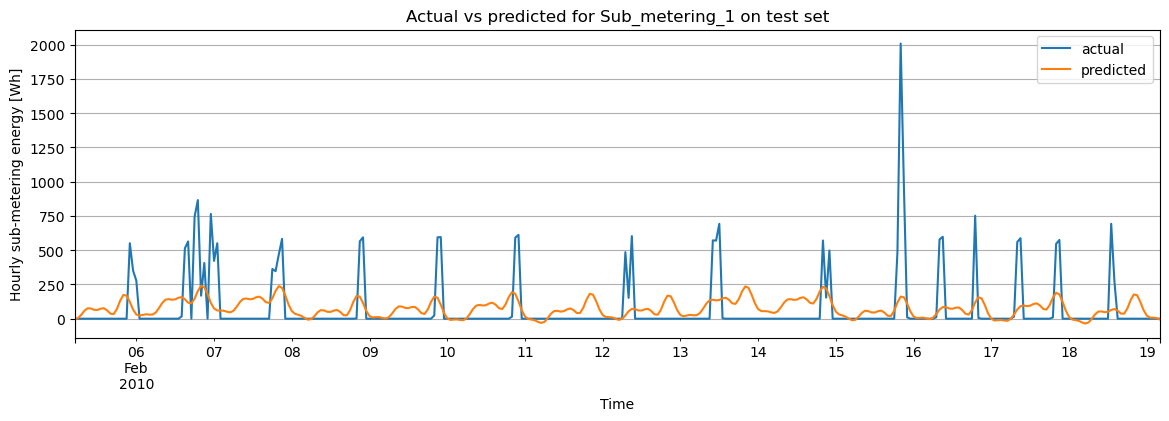

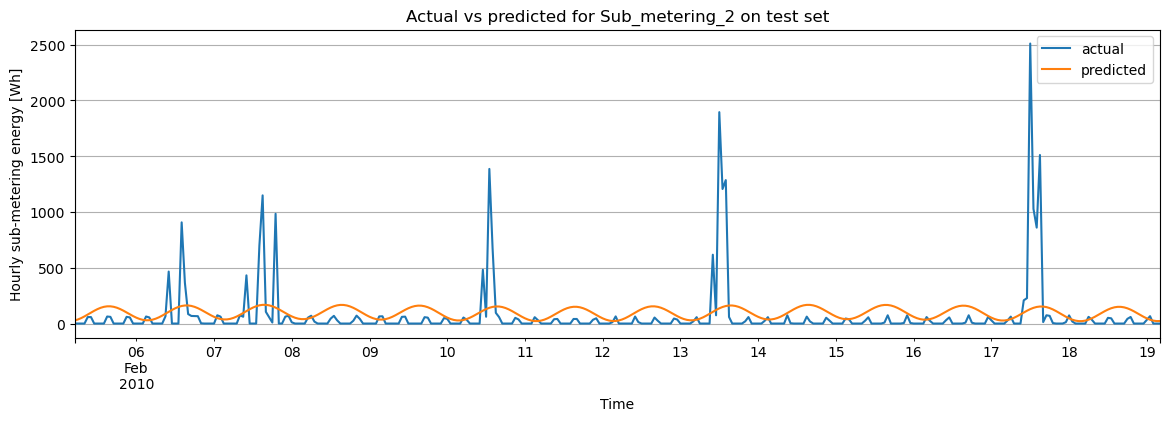

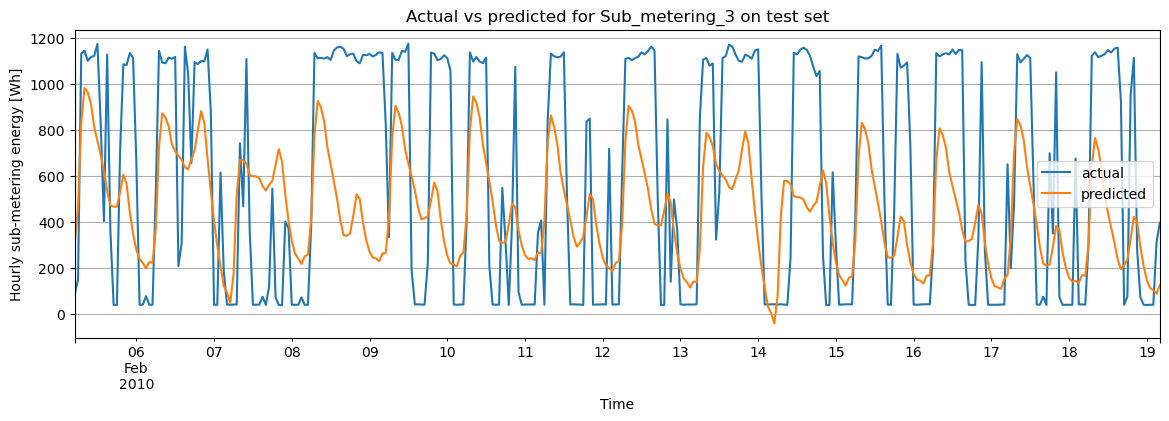

In [55]:
for target in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    best_row = best_submeter_results[
        best_submeter_results["Target"] == target
    ].iloc[0]

    pred_df, model = train_best_submeter_model(target, best_row)

    pred_df.iloc[:24*14].plot(figsize=(14, 4))

    plt.title(f"Actual vs predicted for {target} on test set")
    plt.xlabel("Time")
    plt.ylabel("Hourly sub-metering energy [Wh]")
    plt.grid(True)
    plt.savefig(figures_dir / f"further_best_prediction_{target}.png", dpi=300, bbox_inches='tight')
    plt.show()

If predicted line is smooth but actual line has sharp spikes:
    the model captures average periodic behavior but misses irregular appliance usage.

If predicted and actual have similar daily shape:
    time features explain that target reasonably well.

If prediction is almost flat:
    the target is too irregular or sparse for calendar-only Fourier features.

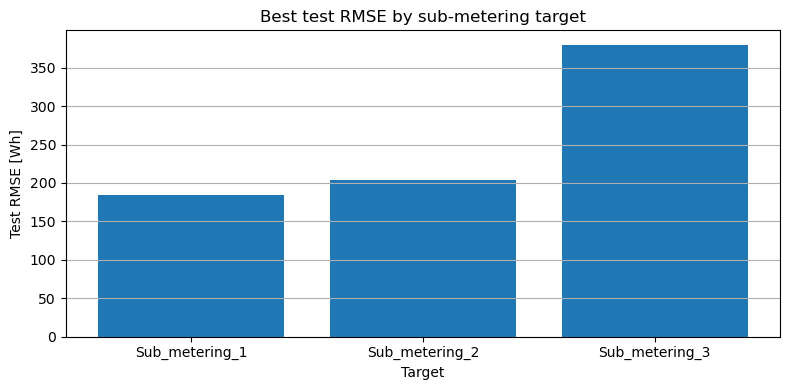

In [56]:
plt.figure(figsize=(8, 4))
plt.bar(best_submeter_results["Target"], best_submeter_results["Test RMSE"])

plt.title("Best test RMSE by sub-metering target")
plt.xlabel("Target")
plt.ylabel("Test RMSE [Wh]")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(figures_dir / "further_best_test_rmse_by_target.png", dpi=300, bbox_inches='tight')
plt.show()